In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [5]:
#Normalization of the data between 0 and 1  --- Note: I will use mobilnet later to scale the data between -1 and 1, but for now I will use 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()



In [6]:
print(y_train.shape)

(50000,)


In [7]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'] # cifar gives labels as text 

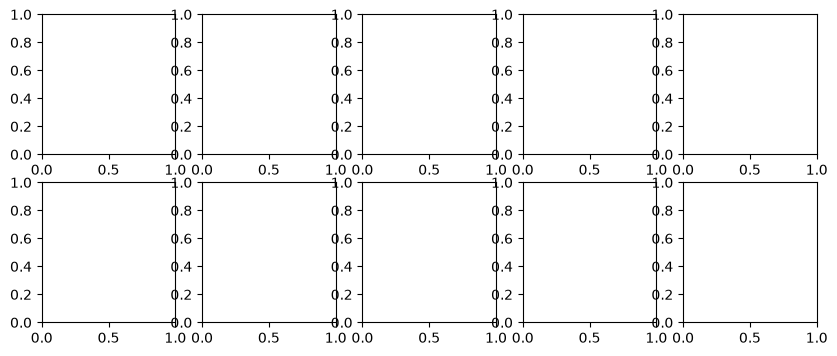

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))

In [9]:
# print(axes.shape)
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
    
for i in range(10):
    print(f"Class {i}: {class_names[i]}")

Class 0: airplane
Class 1: automobile
Class 2: bird
Class 3: cat
Class 4: deer
Class 5: dog
Class 6: frog
Class 7: horse
Class 8: ship
Class 9: truck


In [10]:
# plt.imshow(x_train[0])
# plt.title(class_names[y_train[0]])
# plt.show()    

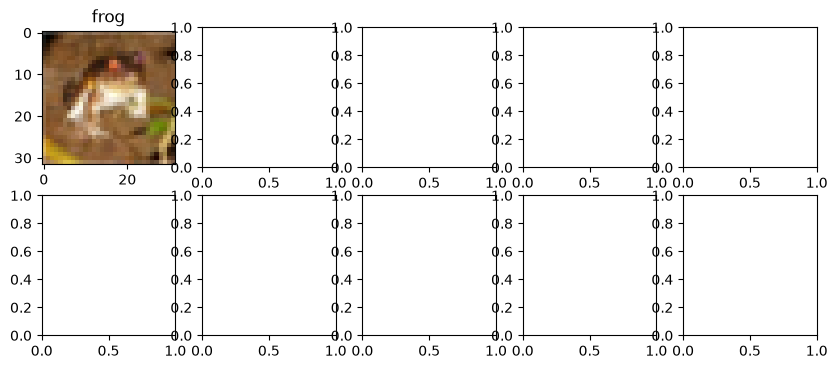

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))
axes[0, 0].imshow(x_train[0])
axes[0, 0].set_title(class_names[y_train[0]])
plt.show()


In [12]:
print(x_train.dtype, x_train.max(), x_train.min())

float32 1.0 0.0


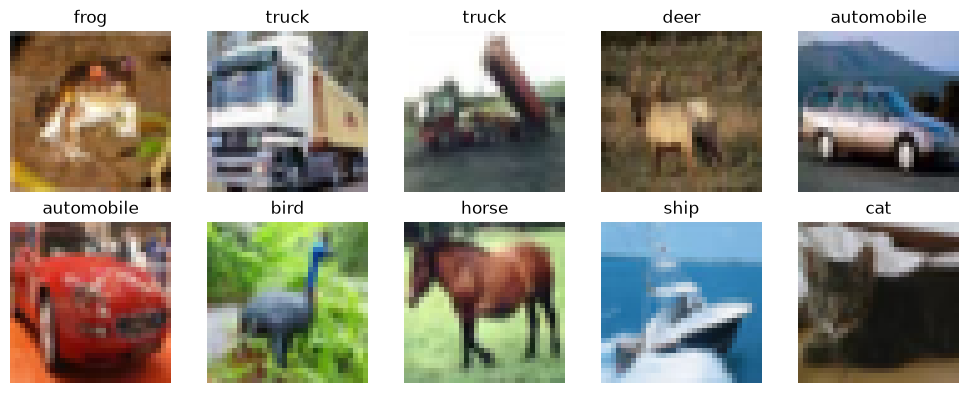

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))

for i, ax in enumerate(axes.flat): # transforming the 2D array of axes into a flat iterator ( simple sequence of 10 boxes)
    ax.imshow(x_train[i]) #image
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
from tensorflow.keras import layers, models

cnn = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#training the CNN model
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = cnn.fit(x_train, y_train, epochs=15, batch_size=64,
                   validation_split=0.1, callbacks=[early_stop])

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4559 - loss: 1.5014 - val_accuracy: 0.5790 - val_loss: 1.2106
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6020 - loss: 1.1296 - val_accuracy: 0.6378 - val_loss: 1.0368
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6569 - loss: 0.9828 - val_accuracy: 0.6558 - val_loss: 0.9803
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6874 - loss: 0.8980 - val_accuracy: 0.6824 - val_loss: 0.9184
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7111 - loss: 0.8298 - val_accuracy: 0.6796 - val_loss: 0.9248
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7276 - loss: 0.7809 - val_accuracy: 0.7020 - val_loss: 0.8629
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7457 - loss: 0.7355 - val_accuracy: 0.6946 - val_loss: 0.8903
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7592 - loss: 0.6898 - val_ac

In [16]:
# Training stopped early at epoch 14 (EarlyStopping triggered after 3 epochs with no val_loss improvement).
# Best weights were restored from epoch 11, which had the lowest val_loss and highest validation accuracy (~72%).
# Signs of overfitting appear after epoch 11: training accuracy kept rising while val_loss increased.

In [17]:
#Validation 
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

y_pred = np.argmax(cnn.predict(x_test), axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

    airplane       0.75      0.71      0.73      1000
  automobile       0.83      0.79      0.81      1000
        bird       0.64      0.48      0.55      1000
         cat       0.54      0.52      0.53      1000
        deer       0.62      0.68      0.65      1000
         dog       0.64      0.60      0.62      1000
        frog       0.78      0.75      0.77      1000
       horse       0.68      0.81      0.74      1000
        ship       0.82      0.77      0.80      1000
       truck       0.69      0.84      0.76      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.69     10000
weighted avg       0.70      0.70      0.69     10000



### * Weakest classes: cat, dog, and deer. The model struggles to distinguish between these similar classes, leading to lower precision and recall.
### * Strongest classes: airplane, automobile, and ship. The model performs well on these distinct classes, achieving high precision and reca

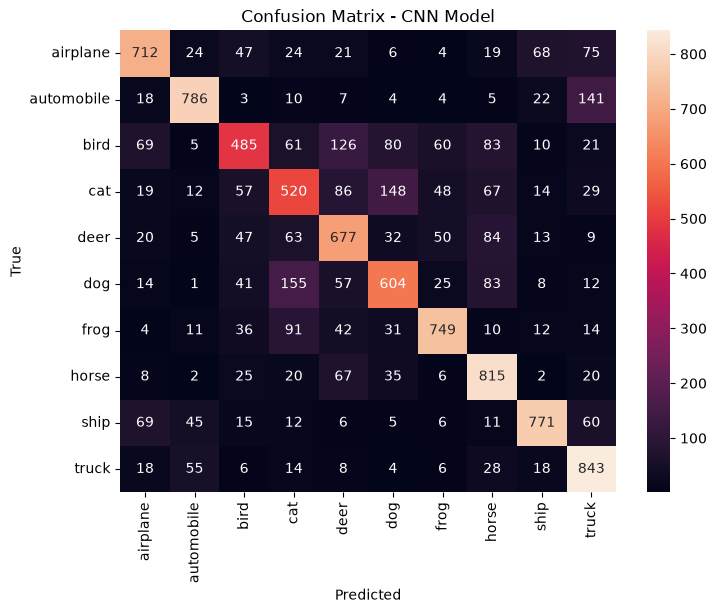

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CNN Model')
plt.savefig('confusion_matrix_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

### * Main error source of the CNN from scratch: confusion between animal classes with variable shapes/poses (cat/dog, bird/deer),
###   while classes with more rigid, consistent shapes (vehicles: automobile, ship, truck) achieve nearly double the precision.

In [19]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()
y_train_raw = y_train_raw.flatten()
y_test_raw = y_test_raw.flatten()

In [20]:
print(x_train_raw.shape, y_train_raw.shape, x_test_raw.shape, y_test_raw.shape)

(50000, 32, 32, 3) (50000,) (10000, 32, 32, 3) (10000,)


### Resize: MobileNetV2 requires a minimum input size of 96×96, but CIFAR-10 images are 32×32, so they need to be upscaled before being fed to the model.
### tf.data.Dataset: instead of resizing all 50,000 images at once (which would be too memory-heavy), we process and resize them in small batches, only when needed during training.

In [21]:
#pipeline 

def preprocess(image, label):
    image = tf.image.resize(image, (96, 96))
    image = preprocess_input(image)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train_raw, y_train_raw)) #transforms normal arrays into a tf.data.Dataset object
train_ds = train_ds.map(preprocess).batch(64).prefetch(1) #preprocess = resize and normalization , batch(64) grouping the data into batches of 64, prefetch(1) = allows the data to be prepared while the model is training on the current batch

test_ds = tf.data.Dataset.from_tensor_slices((x_test_raw, y_test_raw))
test_ds = test_ds.map(preprocess).batch(64).prefetch(1)

In [22]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(96,96,3), include_top=False, weights='imagenet')
base_model.trainable = False

tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
])



tl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

tl_history = tl_model.fit(train_ds, epochs=5, validation_data=test_ds, callbacks=[early_stop])

Epoch 1/5


c:\Users\kalil\anaconda3\envs\deeplearning\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


782/782 ━━━━━━━━━━━━━━━━━━━━ 114s 142ms/step - accuracy: 0.8105 - loss: 0.5544 - val_accuracy: 0.8506 - val_loss: 0.4276
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 112s 143ms/step - accuracy: 0.8660 - loss: 0.3928 - val_accuracy: 0.8595 - val_loss: 0.4073
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 112s 144ms/step - accuracy: 0.8778 - loss: 0.3580 - val_accuracy: 0.8582 - val_loss: 0.4040
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 142ms/step - accuracy: 0.8843 - loss: 0.3373 - val_accuracy: 0.8587 - val_loss: 0.4062
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 112s 143ms/step - accuracy: 0.8890 - loss: 0.3232 - val_accuracy: 0.8585 - val_loss: 0.4106


**Transfer learning reached 85.17% validation accuracy after just 1 epoch**, surpassing the CNN from scratch (~72% after 9-11 epochs). This shows the value of pretrained visual knowledge (ImageNet): faster convergence and better performance, despite training only 12,810 parameters vs 282,250 in the scratch model.

In [24]:
y_pred_tl = np.argmax(tl_model.predict(test_ds), axis=1)
print(classification_report(y_test_raw, y_pred_tl, target_names=class_names))


157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step
              precision    recall  f1-score   support

    airplane       0.84      0.90      0.87      1000
  automobile       0.87      0.96      0.91      1000
        bird       0.86      0.80      0.83      1000
         cat       0.74      0.74      0.74      1000
        deer       0.83      0.83      0.83      1000
         dog       0.81      0.79      0.80      1000
        frog       0.88      0.91      0.89      1000
       horse       0.88      0.89      0.88      1000
        ship       0.92      0.90      0.91      1000
       truck       0.94      0.88      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



# Best performance with transfer learning using MobileNetV2. 86% vs 72% with the CNN model. And the intersting part is that the classes that the CNN model struggled with (cat, dog, bird) are the ones with bigger improvement in the transfer learning model.

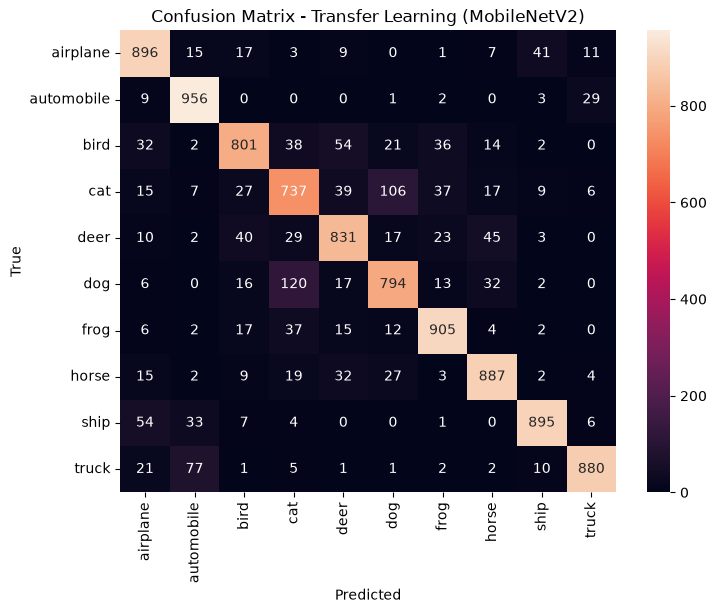

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
cm_tl = confusion_matrix(y_test_raw, y_pred_tl)
plt.figure(figsize=(8,6))
sns.heatmap(cm_tl, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Transfer Learning (MobileNetV2)')
plt.savefig('confusion_matrix_tl.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Comparison Summary

| Metric | CNN from scratch | Transfer Learning (MobileNetV2) |
|---|---|---|
| Test Accuracy | 70% | 86% |
| Trainable Params | 282,250 | 12,810 |
| Epochs to converge | ~9-11 | 1-3 |
| Weakest classes | cat (0.51), bird (0.57) | cat (0.73), bird (0.83) |

**Differences:**
- Transfer learning achieved higher accuracy with far fewer trainable parameters, by reusing visual features learned from ImageNet (edges, textures, shapes).
- The CNN from scratch required more epochs and still underperformed, especially on animal classes with different poses (cat, dog, bird) — these classes benefited the most from pretrained features.
- Trade-off: transfer learning requires resizing images to a larger input size (96x96 minimum for MobileNetV2), increasing per-image compute cost during preprocessing, and depends on an external pretrained model rather than learning purely from the target dataset.